# Analiza meczów StatsBomb

Notebook do eksploracji i analizy danych z meczów

In [13]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

import sys
from pathlib import Path
project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root))

from src.data.data_loader import load_statsbomb_socceraction_data

pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Wczytanie danych

In [15]:
matches = list(load_statsbomb_socceraction_data("../../data/statsbomb/data", 55, 282))

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loading events for match 3942752 (3/51)...
Loading events for match 3942382 (4/51)...
Loading events for match 3942349 (5/51)...
Loading events for match 3930180 (6/51)...
Loading events for match 3930171 (7/51)...
Loading events for match 3942227 (8/51)...
Loading events for match 3942226 (9/51)...
Loading events for match 3938645 (10/51)...
Loading events for match 3930184 (11/51)...
Loading events for match 3941022 (12/51)...
Loading events for match 3941021 (13/51)...
Loading events for match 3941020 (14/51)...
Loading events for match 3941019 (15/51)...
Loading events for match 3941018 (16/51)...
Loading events for match 3941017 (17/51)...
Loading events for match 3930182 (18/51)...
Loading events for match 3930179 (19/51)...
Loading events for match 3940983 (20/51)...
Loading events for match 3940878 (21/51)...
Loading events for match 3930177 (22/5

## Podstawowe informacje

In [16]:
# Wyświetl informacje o pierwszym meczu
game, events = matches[0]
print("Przykładowy mecz:")
print(game)
print(f"\nLiczba zdarzeń: {len(events)}")
print(f"\nKolumny zdarzeń: {events.columns.tolist()}")

Przykładowy mecz:
game_id                          3942819
season_id                            282
competition_id                        55
competition_stage            Semi-finals
game_day                               6
game_date            2024-07-10 22:00:00
home_team_id                         941
away_team_id                         768
home_score                             1
away_score                             2
venue                  Signal-Iduna-Park
referee                     Felix Zwayer
home_team_name               Netherlands
away_team_name                   England
Name: 0, dtype: object

Liczba zdarzeń: 3485

Kolumny zdarzeń: ['game_id', 'event_id', 'period_id', 'team_id', 'player_id', 'type_id', 'type_name', 'index', 'timestamp', 'minute', 'second', 'possession', 'possession_team_id', 'possession_team_name', 'play_pattern_id', 'play_pattern_name', 'team_name', 'duration', 'extra', 'related_events', 'player_name', 'position_id', 'position_name', 'location', 'under_

## Analiza strzałów

In [21]:
len(matches)

51

In [23]:
for game, events in matches:
    print(f"Mecz {game['game_id']},  {game['competition_stage']}: {len(events)} zdarzeń")

Mecz 3942819,  Semi-finals: 3485 zdarzeń
Mecz 3943043,  Final: 3312 zdarzeń
Mecz 3942752,  Semi-finals: 3328 zdarzeń
Mecz 3942382,  Quarter-finals: 3415 zdarzeń
Mecz 3942349,  Quarter-finals: 5190 zdarzeń
Mecz 3930180,  Group Stage: 3198 zdarzeń
Mecz 3930171,  Group Stage: 3881 zdarzeń
Mecz 3942227,  Quarter-finals: 4882 zdarzeń
Mecz 3942226,  Quarter-finals: 4463 zdarzeń
Mecz 3938645,  Group Stage: 3525 zdarzeń
Mecz 3930184,  Group Stage: 2953 zdarzeń
Mecz 3941022,  Round of 16: 3722 zdarzeń
Mecz 3941021,  Round of 16: 2996 zdarzeń
Mecz 3941020,  Round of 16: 4221 zdarzeń
Mecz 3941019,  Round of 16: 3941 zdarzeń
Mecz 3941018,  Round of 16: 3949 zdarzeń
Mecz 3941017,  Round of 16: 4764 zdarzeń
Mecz 3930182,  Group Stage: 3787 zdarzeń
Mecz 3930179,  Group Stage: 3776 zdarzeń
Mecz 3940983,  Round of 16: 3640 zdarzeń
Mecz 3940878,  Round of 16: 3853 zdarzeń
Mecz 3930177,  Group Stage: 3386 zdarzeń
Mecz 3930173,  Group Stage: 3681 zdarzeń
Mecz 3930172,  Group Stage: 3982 zdarzeń
Mecz 39301

In [26]:
game, events = matches[0]
events.head(10).dropna()

,game_id,event_id,period_id,team_id,player_id,type_id,type_name,index,timestamp,minute,second,possession,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_name,duration,extra,related_events,player_name,position_id,position_name,location,under_pressure,counterpress,visible_area_360,freeze_frame_360
4,3942819,25dfc952-7a85-464f-b884-982064d46cc9,1,768,99174.0,30,Pass,5,0 days 00:00:00.355000,0,0,2,768,England,9,From Kick Off,England,2.455156,"{'pass': {'recipient': {'id': 3468, 'name': 'J...",[85328a9c-e246-4273-b566-353b64d902a1],Kobbie Mainoo,9.0,Right Defensive Midfield,"[60.0, 40.0]",False,False,"[82.05880352279489, 80.0, 37.469993200629204, ...","[{'teammate': True, 'actor': False, 'keeper': ..."
6,3942819,23b8ddd8-4daa-4dce-b4f3-fc40546b9a3f,1,768,3468.0,43,Carry,7,0 days 00:00:02.810000,0,2,2,768,England,9,From Kick Off,England,2.483781,"{'carry': {'end_location': [30.4, 24.1]}}","[37b46889-6085-4985-a50f-7fc2b14fc20e, 85328a9...",Jordan Pickford,1.0,Goalkeeper,"[25.7, 34.5]",True,False,"[79.67044795748183, 80.0, 38.490725216644606, ...","[{'teammate': True, 'actor': True, 'keeper': T..."
7,3942819,37b46889-6085-4985-a50f-7fc2b14fc20e,1,941,2988.0,17,Pressure,8,0 days 00:00:04.188000,0,4,2,768,England,9,From Kick Off,Netherlands,1.267798,{},"[23b8ddd8-4daa-4dce-b4f3-fc40546b9a3f, 8a92016...",Memphis Depay,23.0,Center Forward,"[81.2, 47.6]",False,False,"[9.62222432154445, 80.0, 43.209688438209994, 0...","[{'teammate': True, 'actor': False, 'keeper': ..."
8,3942819,8a920161-a913-4ce5-be61-9d6ae7466469,1,768,3468.0,30,Pass,9,0 days 00:00:05.294000,0,5,2,768,England,9,From Kick Off,England,3.438864,"{'pass': {'length': 65.69574, 'angle': 0.46228...","[37b46889-6085-4985-a50f-7fc2b14fc20e, c6e3a4a...",Jordan Pickford,1.0,Goalkeeper,"[30.4, 24.1]",True,False,"[40.07701261372162, 75.76529270581614, 10.9116...","[{'teammate': True, 'actor': True, 'keeper': T..."
9,3942819,c6e3a4a2-d078-4c2d-b94d-ff721bcdf50b,1,941,3669.0,30,Pass,10,0 days 00:00:08.732000,0,8,2,768,England,9,From Kick Off,Netherlands,2.819638,"{'pass': {'recipient': {'id': 2988, 'name': 'M...","[754bbe86-42ff-4c17-9d64-8f22fa0f1ee0, 8a92016...",Virgil van Dijk,5.0,Left Center Back,"[30.9, 26.7]",False,False,"[0.0, 80.0, 0.0, 42.04634322968843, 27.5085434...","[{'teammate': True, 'actor': False, 'keeper': ..."


Policz wszystkie strzały we wszystkich meczach


In [36]:
shots_list = []

for game, events in matches:
    match_shots = events[events['type_name'] == 'Shot']
    shots_list.append(match_shots)

shots_df = pd.concat(shots_list, ignore_index=True)
print(f"\nŁączna liczba strzałów we wszystkich meczach: {shots_df.shape[0]}")


Łączna liczba strzałów we wszystkich meczach: 1340


## Analiza typów zdarzeń

In [31]:

event_types = []
for game, events in matches:
    event_types.extend(events['type_name'].tolist())

event_counts = pd.Series(event_types).value_counts()
print(f"\nTop 10 typów zdarzeń: {event_counts.head(10)}")
len(event_counts)


Top 10 typów zdarzeń: Pass             53890
Ball Receipt*    51618
Carry            44139
Pressure         14544
Ball Recovery     4130
Duel              3059
Block             1992
Clearance         1852
Goal Keeper       1618
Shot              1340
Name: count, dtype: int64


33

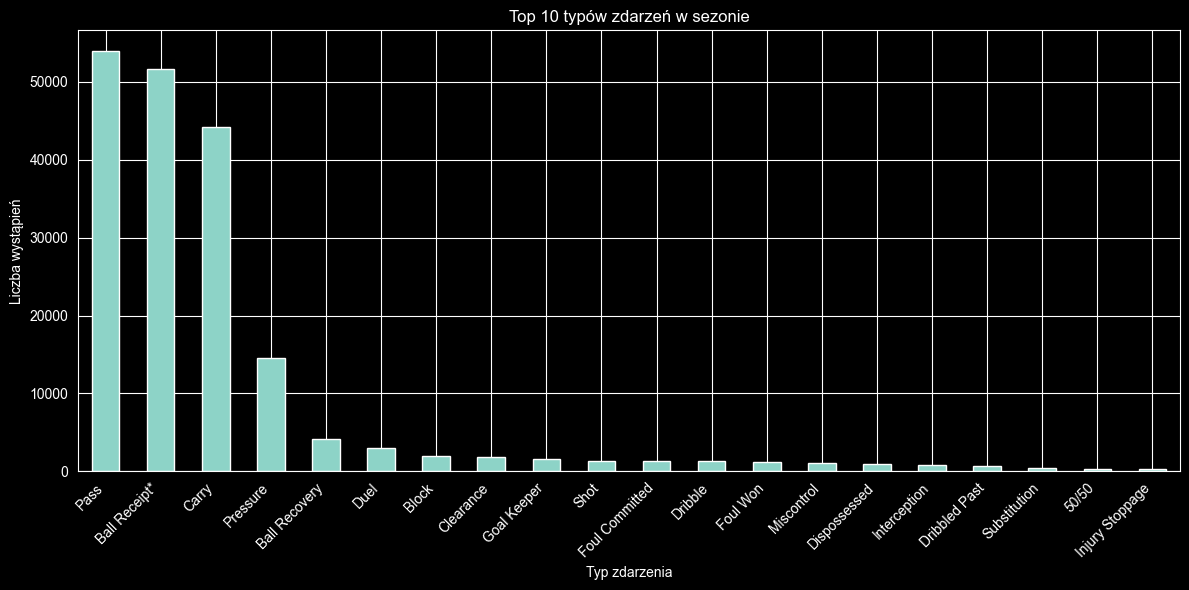

In [35]:
# Wykres topowych typów zdarzeń
plt.figure(figsize=(12, 6))
event_counts.head(20).plot(kind='bar')
plt.xlabel('Typ zdarzenia')
plt.ylabel('Liczba wystąpień')
plt.title('Top 10 typów zdarzeń w sezonie')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analiza ilości posiadań piłki